# *Merging* de matrices de tiempo de viaje

Este *notebook* presenta tres funcionalidades relacionadas a la
fusión/unificación de distintos objetos `TravelTimeMatrices` (o de los destinos
al interior de un objeto). Para cada funcionalidad, se presenta un caso de uso
realista aplicado al Gran Santiago.

In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import datetime
from pathlib import Path

import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

import xmin
from xmin.dataset import extract_osm_subset
from xmin.indices import EnhancedTwoStepFca
from xmin import travel_time

In [3]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
IMG_PATH = Path("../../reports/figures")
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [68]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_SALUD_PATH = PRE_DATA_PATH / "amenities" / "salud.gpkg"
AMENITY_VERDES_PATH = PRE_DATA_PATH / "amenities" / "areas_verdes.gpkg"
OSM_SANTIAGO_PATH = PRE_DATA_PATH / "osm" / "Santiago.osm.pbf"

## Orígenes y destinos

In [5]:
# carga de datos
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24",
)

# filtramos solo las áreas de interés
limites_urbanos = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN SANTIAGO")
]

# obtenemos envoltura convexa para extraer POIs y red vial
limites_envoltura = limites_urbanos.union_all().convex_hull

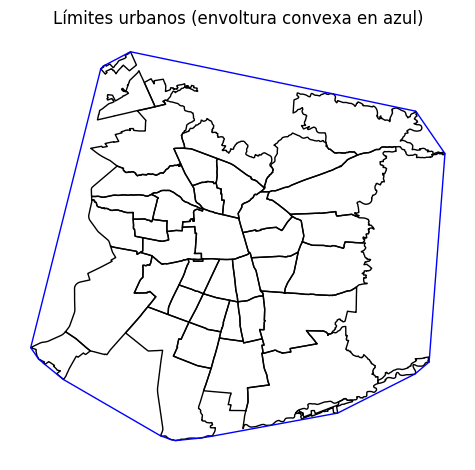

In [6]:
ax = limites_urbanos.plot(facecolor="none", edgecolor="black")
gpd.GeoSeries([limites_envoltura]).plot(
    ax=ax, facecolor="none", edgecolor="blue"
)
ax.set_axis_off()
plt.title("Límites urbanos (envoltura convexa en azul)")
plt.tight_layout()

In [7]:
manzanas = gpd.read_file(
    CENSO_PATH,
    layer="Manzanas_CPV24",
    mask=limites_urbanos.union_all(),
    use_arrow=True
)

En vez de generar solo un objeto de orígenes, generamos tres: uno guardando la
población joven, otro para la población mayor, y uno combinando ambos.

In [ ]:
origins_joven = xmin.Origins.create_grid(
    regions=limites_urbanos,
    h3_resolution=9,
    population_gdf=manzanas.assign(
        population=manzanas["n_edad_18_24"]
        + manzanas["n_edad_25_44"]
        + manzanas["n_edad_45_59"]
    ),
)

origins_mayor = xmin.Origins.create_grid(
    regions=limites_urbanos,
    h3_resolution=9,
    population_gdf=manzanas.rename(columns={"n_edad_60_mas": "population"}),
)

origins_full = xmin.Origins.create_grid(
    regions=limites_urbanos,
    h3_resolution=9,
    population_gdf=manzanas.assign(
        population=manzanas["n_edad_18_24"]
        + manzanas["n_edad_25_44"]
        + manzanas["n_edad_45_59"]
        + manzanas["n_edad_60_mas"]
    ),
)

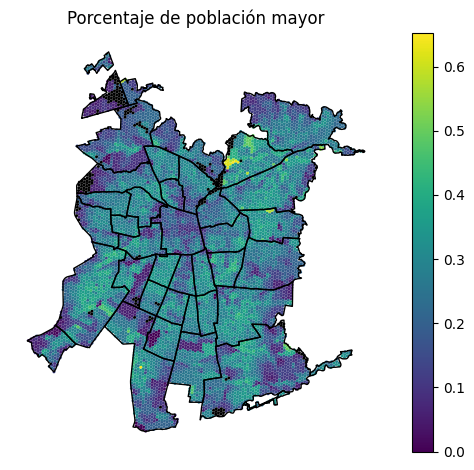

In [66]:
origins_comp = (
    origins_joven.h3_grid.set_index("id")
    .rename(columns={"population": "population_joven"})
    .assign(
        population_mayor=origins_mayor.h3_grid.set_index("id")["population"],
        pct_mayor=lambda gdf: gdf["population_mayor"]
        / (gdf["population_mayor"] + gdf["population_joven"]),
    )
)
ax = origins_comp.plot(
    "pct_mayor", legend=True, missing_kwds={"color": "black"}
)
limites_urbanos.plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
plt.title("Porcentaje de población mayor")
plt.tight_layout()

In [10]:
if not OSM_SANTIAGO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_SANTIAGO_PATH,
        bounds=limites_envoltura
    )

In [11]:
farmacias = xmin.Amenity.from_osm(
    name="farmacias",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": ["pharmacy"]},
    keep_all_tags=["name"]
)

In [ ]:
salud_gdf = gpd.read_file(AMENITY_SALUD_PATH, mask=limites_envoltura)

salud = xmin.Amenity(
    name="salud",
    amenity_gdf=salud_gdf[salud_gdf["TIPO"].isin(["Hospital", "Clínica"])]
)

## Caso 1: análisis diferenciado según grupo etario (`merge_populations`)

Un área de estudio dentro de la ciudad de 15 minutos es la forma de incluir
personas con movilidad reducida. Nos gustaría poder obtener los índices de
accesibilidad de una persona con menor velocidad de movimiento, y compararla
con la accesibilidad que posee una persona con una velocidad de movimiento
promedio.

Si no se utilizan índices que consideren oferta y demanda, esto es sencillo:
como la accesibilidad de cada celda depende únicamente de los tiempos de viaje
desde la celda en cuestión, basta con reducir la velocidad de movimiento de
todas las celdas al momento de calcular las TTMs para que, en cada celda, se
pueda obtener la accesibilidad con velocidad reducida.

Sin embargo, al utilizar índices que consideran oferta y demanda, asumir que
todos van a una velocidad menor deja de ser realista, pues la accesibilidad de
una celda va a depender de los tiempos de viaje en celdas cercanas (que
compiten por el acceso a las necesidades), y sabemos que no todas las personas
en cada celda tendrán movilidad reducida. Luego, lo que nos gustaría hacer es
calcular, para cada celda, dos índices de accesibilidad: uno para personas con
velocidad mayor, y otro para personas con velocidad menor. Estos índices deben
ser calculados **al mismo tiempo**, para considerar la competencia real que
existe entre estos dos grupos de personas por el acceso a servicios.

### Cálculo de TTMs

Primero, calculamos tiempos de viaje separados para personas jóvenes (entre 18
y 59 años, asumiendo una velocidad de caminata de 3.6km/h) y para personas
mayores (60 años o más, asumiendo una velocidad de caminata de 2.4km/h).

In [ ]:
ttms_joven = xmin.TravelTimeMatrices.compute(
    origins=origins_joven,
    amenities=[farmacias],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=15),
    transport_modes=["WALK"],
    speed_walking=3.6
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

In [ ]:
ttms_mayor = xmin.TravelTimeMatrices.compute(
    origins=origins_mayor,
    amenities=[farmacias],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=15),
    transport_modes=["WALK"],
    speed_walking=2.4
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

Unimos los dos resultados, así obteniendo una gran TTM con tiempos de viaje
para cada grupo.

In [15]:
ttms_merged = travel_time.merge_populations(
    {"joven": ttms_joven, "mayor": ttms_mayor}
)

In [27]:
ttms_merged.matrices["farmacias"]

,from_id,to_id,travel_time
0,joven/89b2c50b27bffff,farmacias/way/447599096,10.0
1,joven/89b2c50b27bffff,farmacias/way/446603668,2.0
2,joven/89b2c50b27bffff,farmacias/node/4446880426,15.0
5,joven/89b2c5096d3ffff,farmacias/node/685958680,14.0
6,joven/89b2c5096d3ffff,farmacias/node/685958679,14.0
...,...,...,...
12071,mayor/89b2c556b2bffff,farmacias/way/313205112,8.0
12072,mayor/89b2c556b2bffff,farmacias/way/313205110,8.0
12073,mayor/89b2c556b2bffff,farmacias/way/400842305,3.0
12074,mayor/89b2c556b2bffff,farmacias/node/1583512986,9.0


También generaremos dos objetos extra: uno asumiendo que toda la población
viaja a la velocidad de una persona jóven, y otro asumiendo que toda la
población viaja a la velocidad de una persona mayor. Estos serán utilizados
para comparar el enfoque "naïve" de asumir que todas las personas viajan a una
velocidad particular, versus el enfoque combinado.

In [29]:
ttms_all_joven = xmin.TravelTimeMatrices(
    origins=origins_full,
    amenities=ttms_joven.amenities.values(),
    matrices=ttms_joven.matrices,
)

ttms_all_mayor = xmin.TravelTimeMatrices(
    origins=origins_full,
    amenities=ttms_mayor.amenities.values(),
    matrices=ttms_mayor.matrices,
)

### Cálculo de índices

Calculamos el mismo índice para las tres TTMs.

In [30]:
e2sfca_function = EnhancedTwoStepFca(
    catchment_areas=[
        (0, 10, 1.00),
        (10, 20, 0.42),
        (20, 30, 0.03),
    ],
    desired_ratio=3_000,
)

In [31]:
acc_all_joven = xmin.AccessibilityRatings.compute(
    ttms_all_joven,
    index_function=e2sfca_function
)

Calculando índices para cada necesidad...


  0%|          | 0/2 [00:00<?, ?it/s]

In [32]:
acc_all_mayor = xmin.AccessibilityRatings.compute(
    ttms_all_mayor,
    index_function=e2sfca_function
)

Calculando índices para cada necesidad...


  0%|          | 0/2 [00:00<?, ?it/s]

In [33]:
acc_combined = xmin.AccessibilityRatings.compute(
    ttms_merged,
    index_function=e2sfca_function
)

Calculando índices para cada necesidad...


  0%|          | 0/2 [00:00<?, ?it/s]

Separamos el índice calculado de manera combinada, entre los resultados
obtenidos para personas jóvenes y los resultados obtenidos para personas
mayores.

In [39]:
split_accs = acc_combined.split()

In [40]:
acc_combined_joven = split_accs["joven"]
acc_combined_mayor = split_accs["mayor"]

### Visualizaciones

Notamos que, al comparar los dos índices *naïve* (donde toda la población viaja
a una misma velocidad), hay muchos más orígenes con buena accesibilidad si las
personas viajan más rápido; esto es esperado. Sin embargo, al comparar el
enfoque combinado con el *naïve* para cada grupo etario, las personas jóvenes
no ven mayores diferencias en su accesibilidad, mientras que para las personas
mayores el índice combinado entrega valores menores al *naïve* en varias
regiones.

Esto demuestra que, al considerar competencia entre personas jóvenes y mayores,
estas últimas se ven afectadas de forma aún mayor por una baja cantidad de
servicios cercanos. Las personas jóvenes pueden visitar destinos más lejanos
sin mayores problemas; este no es un lujo que se puedan dar las personas con
movilidad reducida.

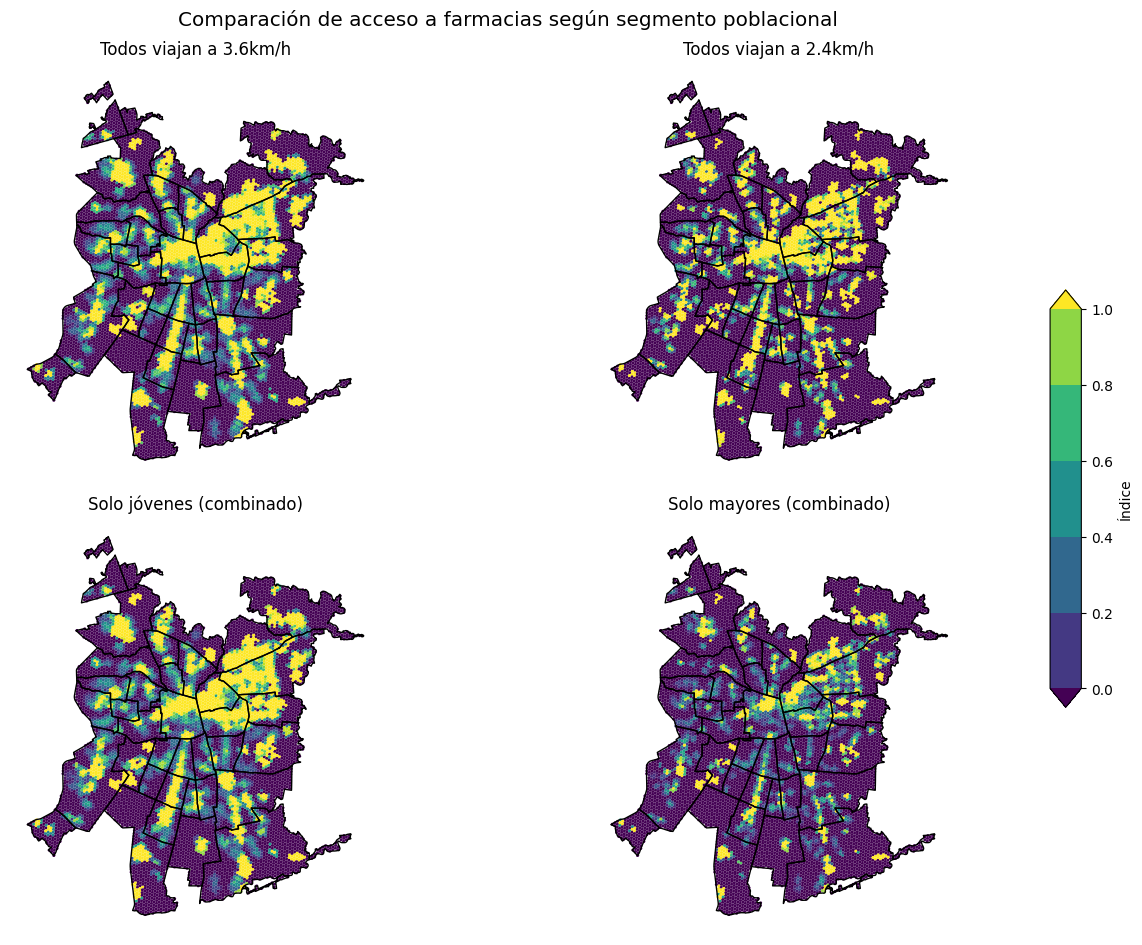

In [ ]:
fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_all_joven = fig.add_subplot(gs[0:2, 0])
ax_all_mayor = fig.add_subplot(gs[0:2, 1])
ax_combined_joven = fig.add_subplot(gs[2:4, 0])
ax_combined_mayor = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

norm = mcolors.BoundaryNorm(
    [1e-10, 0.2, 0.4, 0.6, 0.8, 1.0], ncolors=256, extend="both"
)

for ax, acc, name in zip(
    (ax_all_joven, ax_all_mayor, ax_combined_joven, ax_combined_mayor),
    (acc_all_joven, acc_all_mayor, acc_combined_joven, acc_combined_mayor),
    (
        "Todos viajan como jóvenes (3.6km/h)",
        "Todos viajan como mayores (2.4km/h)",
        "Solo jóvenes (combinado)",
        "Solo mayores (combinado)"
    ),
):
    acc.visualize.choropleth("farmacias", ax=ax)
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Índice")

fig.suptitle(
    "Comparación de acceso a farmacias según segmento poblacional",
    fontsize="x-large",
)

plt.tight_layout()
plt.savefig(IMG_PATH / "age_segment_comparison.pdf")

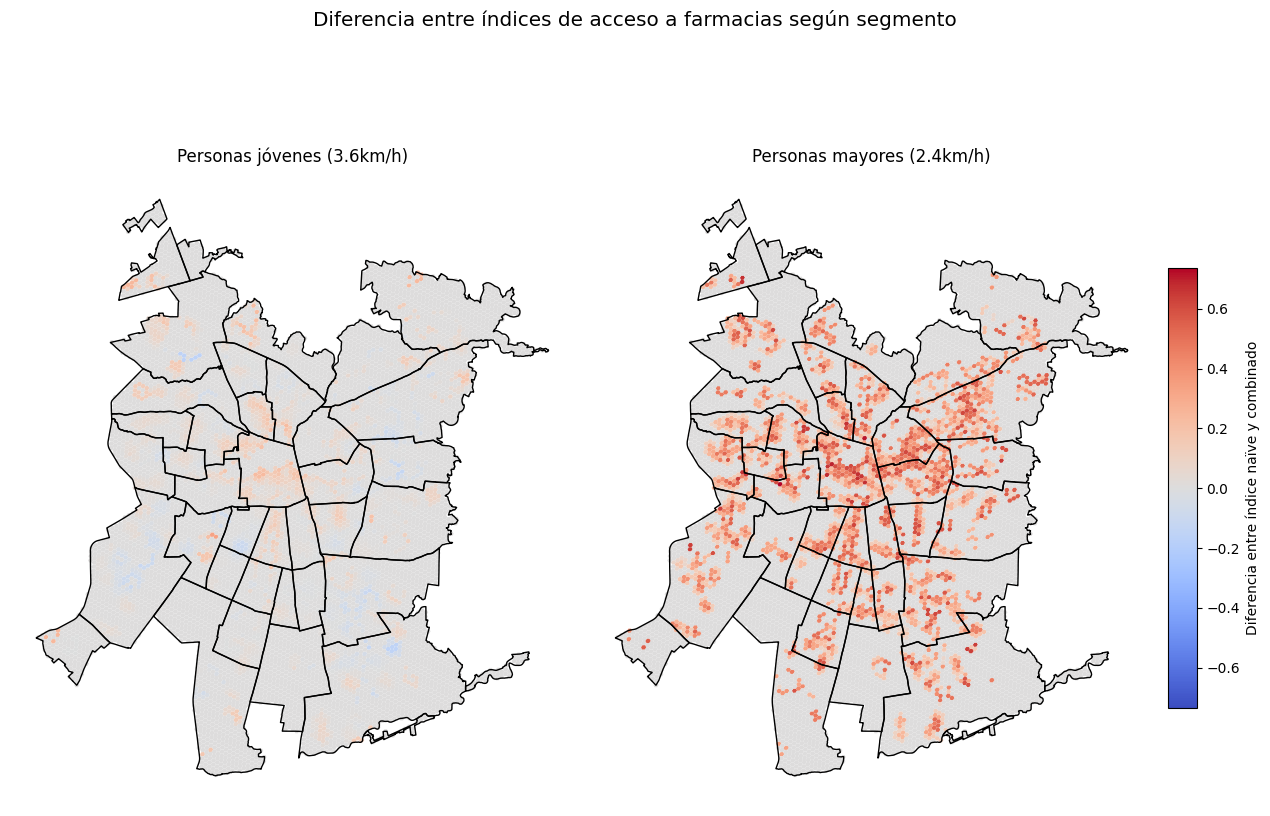

In [65]:
import pandas as pd
cmap = "coolwarm"

fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_diff_joven = fig.add_subplot(gs[0:4, 0])
ax_diff_mayor = fig.add_subplot(gs[0:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

diff_joven = acc_all_joven.gdf["farmacias"] - acc_combined_joven.gdf["farmacias"]
diff_mayor = acc_all_mayor.gdf["farmacias"] - acc_combined_mayor.gdf["farmacias"]

halfrange = pd.concat([diff_joven, diff_mayor]).abs().max()
norm = mcolors.CenteredNorm(vcenter=0, halfrange=halfrange)

acc_all_joven.visualize.choropleth(diff_joven, cmap=cmap, ax=ax_diff_joven, norm=norm)
ax_diff_joven.set_axis_off()
ax_diff_joven.set_title("Personas jóvenes (3.6km/h)")

acc_all_mayor.visualize.choropleth(diff_mayor, cmap=cmap, ax=ax_diff_mayor, norm=norm)
ax_diff_mayor.set_axis_off()
ax_diff_mayor.set_title("Personas mayores (2.4km/h)")

cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Diferencia entre índice naïve y combinado")

fig.suptitle(
    "Diferencia entre índices de acceso a farmacias según segmento",
    fontsize="x-large",
)

plt.tight_layout()
plt.savefig(IMG_PATH / "age_segment_difference.pdf")

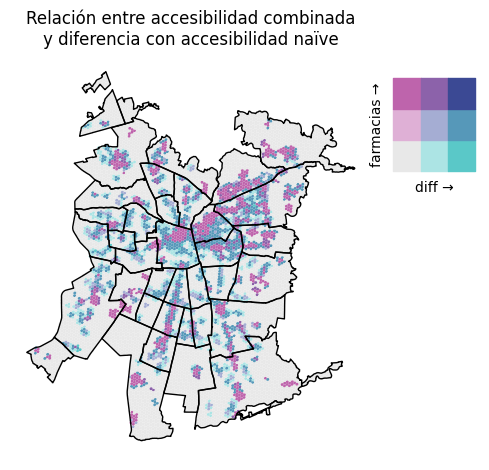

In [99]:
from mapclassify.classifiers import NaturalBreaks

ax = acc_combined_mayor.visualize.bivariate_choropleth(
    "farmacias", diff_mayor.rename("diff"), classifier=NaturalBreaks
)
ax.set_axis_off()
ax.set_title(
    "Relación entre accesibilidad combinada\n"
    "y diferencia con accesibilidad naïve"
)

plt.tight_layout()
plt.savefig(IMG_PATH / "age_segment_bivariate.pdf")